In [35]:
import os
import sys
import yaml
import pandas as pd
import numpy as np

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']

sys.path.append(os.path.join(LOCAL_PATH, "src/python"))

import writing_tools as wt

from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

os.environ['LOKY_MAX_CPU_COUNT'] = '1' # because of windows core count warning

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)
with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']
DATA_PATH = local_config['DATA_PATH']
EMBEDDING_DIMENSION = config['EMBEDDING_DIMENSION']

rng = np.random.default_rng(12898)

N_CLUSTERS = 3
N_COMPONENTS = 10

In [36]:
meetings_df = pd.read_csv(os.path.join(DATA_PATH, "intermediate_data/cpc/meetings-manifest.csv"))

agenda_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "agenda_items.parquet"))

docs_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "supplemental_docs.parquet"))

docs_by_item_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "docs_by_item.parquet"))

df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data_w_distances_suffixes.parquet"))

reasons_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "reasons.parquet"))

In [37]:
# Basic info

NUMBER_OF_MEETINGS = meetings_df['date'].nunique()
FIRST_MEETING_DATE = pd.to_datetime(meetings_df['date']).min()
LAST_MEETING_DATE = pd.to_datetime(meetings_df['date']).max()
NUMBER_OF_YEARS = LAST_MEETING_DATE.year - FIRST_MEETING_DATE.year + 1
NUMBER_OF_CASES = len(df)

RESULTS = {
    "NumberOfMeetings": f"{NUMBER_OF_MEETINGS}",
    "FirstMeetingDate": FIRST_MEETING_DATE.strftime('%Y-%m-%d'),
    "LastMeetingDate": LAST_MEETING_DATE.strftime('%Y-%m-%d'),
    "NumberOfYears": f"{NUMBER_OF_YEARS}",
    "NumberOfCases": f"{NUMBER_OF_CASES:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS


{'NumberOfMeetings': '175',
 'FirstMeetingDate': '2018-05-10',
 'LastMeetingDate': '2026-02-26',
 'NumberOfYears': '9',
 'NumberOfCases': '818'}

In [38]:
# Number of agenda items (total, including non-cases)

AGENDA_ITEMS = len(agenda_df)

RESULTS = {
    "NumberOfAgendaItems": f"{AGENDA_ITEMS:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS

{'NumberOfAgendaItems': '1,730'}

In [39]:
# Number of (usable) supplemental documents

SUPPLEMENTAL_DOCS = len(docs_df)
PUBLIC_COMMENTS = (docs_df['document_type']=="PUBLIC COMMENT").sum()
AVG_LETTERS_PER_CASE = df['n_docs'].mean()

RESULTS = {
    "NumberOfSupplementalDocs": f"{SUPPLEMENTAL_DOCS:,.0f}",
    "NumberOfPublicComments": f"{PUBLIC_COMMENTS:,.0f}",
    "AvgLettersPerCase": f"{AVG_LETTERS_PER_CASE:,.1f}"
}

_ = wt.update_results(RESULTS)
RESULTS


{'NumberOfSupplementalDocs': '5,874',
 'NumberOfPublicComments': '5,020',
 'AvgLettersPerCase': '7.8'}

In [40]:
docs_by_item_df['support'] = docs_by_item_df['support_or_oppose'].isin(["DEFINITELY SUPPORT", "SOMEWHAT SUPPORT"])
docs_by_item_df['oppose'] = docs_by_item_df['support_or_oppose'].isin(["DEFINITELY OPPOSE", "SOMEWHAT OPPOSE"])
temp_df = docs_by_item_df.groupby(['date', 'year', 'doc_id']).agg(
    n_support = ('support', 'sum'),
    n_oppose = ('oppose', 'sum')
).reset_index()

NUMBER_SUPPORT = (temp_df['n_support']>0).sum()
NUMBER_OPPOSE = (temp_df['n_oppose']>0).sum()

RESULTS = {
    "NumberInSupport": f"{NUMBER_SUPPORT:,.0f}",
    "NumberInOpposition": f"{NUMBER_OPPOSE:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS


{'NumberInSupport': '2,246', 'NumberInOpposition': '2,717'}

In [41]:
# Page counts

PAGE_COUNT = meetings_df["agenda_pages"].sum() + meetings_df["minutes_pages"].sum() + meetings_df["supdocs_pages"].sum()
RESULTS = {
    "PageCount": f"{PAGE_COUNT:,.0f}"
}
_ = wt.update_results(RESULTS)
RESULTS
    

{'PageCount': '29,131'}

In [42]:
df['project_result'].fillna('na').value_counts()

project_result
APPROVED                                           354
APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS    296
DELAYED                                            122
APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS     32
DENIED                                              10
APPLICATION WITHDRAWN                                4
Name: count, dtype: int64

In [43]:
# Motion results vs. unanimity

df['unanimity'] = ''
df.loc[ df['num_noes']==0, 'unanimity'] = 'Unanimous'
df.loc[ df['num_noes']==1, 'unanimity'] = '1 Nay'
df.loc[ df['num_noes']>1, 'unanimity'] = '>1 Nays'

header = r"""
\begin{table}[H]
\caption{Summary of Motion Outcomes and Vote Results}
\vspace{0.2cm}
\label{tab_result_unanimity}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrrrr} \toprule
 & \multicolumn{3}{c}{Unanimity} & & \\
 Project Outcome & Unanimous & 1 Nay & >1 Nays & Total &  \\ \midrule
 """
footer = r"""
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows the number of cases decided on by the City Planning Commission, organized by the implication of the motion for the project proposal and the unanimity of the vote.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""
tbl = ""

# Approved
tbl += " ~ ~ Approved"
mask = df['project_result'] == 'APPROVED'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Approved with minor conditions
tbl += " ~ ~ Approved with minor conditions"
mask = df['project_result'] == 'APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Approved with major conditions
tbl += " ~ ~ Approved with major conditions"
mask = df['project_result'] == 'APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Deliberations continued
tbl += " ~ ~ Deliberations continued to future date"
mask = df['project_result'].isin(['DELAYED'])
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Denied
tbl += " ~ ~ Denied"
mask = df['project_result'].isin(['DENIED'])
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Withdrawn
tbl += " ~ ~ Application withdrawn"
mask = df['project_result'].isin(['APPLICATION WITHDRAWN'])
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Total
tbl += "TOTAL"
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df['unanimity']==u).sum():,.0f}"
tbl += f" & {len(df):,.0f}"
tbl += f" & \\\\ [1ex]\n"

# Percents
tbl += ""
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & ({(df['unanimity']==u).sum()/len(df)*100:.1f}\\%)"
tbl += " & & \\\\ [1ex] "

print(header + tbl + footer)

with open(os.path.join(LOCAL_PATH, "tables", "tab_result_unanimity.tex"), "w", encoding='utf-8') as f:
    f.write(header + tbl + footer)



\begin{table}[H]
\caption{Summary of Motion Outcomes and Vote Results}
\vspace{0.2cm}
\label{tab_result_unanimity}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrrrr} \toprule
 & \multicolumn{3}{c}{Unanimity} & & \\
 Project Outcome & Unanimous & 1 Nay & >1 Nays & Total &  \\ \midrule
  ~ ~ Approved & 333 & 17 & 4 & 354 & (43.3\%) \\ [1ex]
 ~ ~ Approved with minor conditions & 263 & 21 & 12 & 296 & (36.2\%) \\ [1ex]
 ~ ~ Approved with major conditions & 25 & 2 & 5 & 32 & (3.9\%) \\ [1ex]
 ~ ~ Deliberations continued to future date & 119 & 3 & 0 & 122 & (14.9\%) \\ [1ex]
 ~ ~ Denied & 7 & 1 & 2 & 10 & (1.2\%) \\ [1ex]
 ~ ~ Application withdrawn & 4 & 0 & 0 & 4 & (0.5\%) \\ [1ex]
TOTAL & 751 & 44 & 23 & 818 & \\ [1ex]
 & (91.8\%) & (5.4\%) & (2.8\%) & & \\ [1ex] 
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows the number of cases decided on by the City Planning Commission, organized by the implication of the motion

In [44]:
CasesDenied = f"{(df['project_result'].isin(['DENIED'])).sum():,.0f}"
CasesDeniedPct = f"{(df['project_result'].isin(['DENIED'])).mean()*100:.1f}"
CasesWithdrawn = f"{(df['project_result'].isin(['APPLICATION WITHDRAWN'])).sum():,.0f}"
CasesWithdrawnPct = f"{(df['project_result'].isin(['APPLICATION WITHDRAWN'])).mean()*100:.1f}"
CasesContinued = f"{(df['project_result'].isin(['DELAYED'])).sum():,.0f}"
CasesContinuedPct = f"{(df['project_result'].isin(['DELAYED'])).mean()*100:.1f}"
CasesApprovedPct = f"{(df['project_result']=='APPROVED').mean()*100:.1f}"
CasesApprovedMinorPct = f"{(df['project_result']=='APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS').mean()*100:.1f}"
CasesApprovedMajorPct = f"{(df['project_result']=='APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS').mean()*100:.1f}"
CasesUnanimousPct = f"{(df['unanimity']=='Unanimous').mean()*100:.1f}"

RESULTS = {
    "CasesDenied": CasesDenied,
    "CasesDeniedPct": CasesDeniedPct,
    "CasesWithdrawn": CasesWithdrawn,
    "CasesWithdrawnPct": CasesWithdrawnPct,
    "CasesContinued": CasesContinued,
    "CasesContinuedPct": CasesContinuedPct,
    "CasesApprovedPct": CasesApprovedPct,
    "CasesApprovedMinorPct": CasesApprovedMinorPct,
    "CasesApprovedMajorPct": CasesApprovedMajorPct,
    "CasesUnanimousPct": CasesUnanimousPct
}

_ = wt.update_results(RESULTS)
RESULTS


{'CasesDenied': '10',
 'CasesDeniedPct': '1.2',
 'CasesWithdrawn': '4',
 'CasesWithdrawnPct': '0.5',
 'CasesContinued': '122',
 'CasesContinuedPct': '14.9',
 'CasesApprovedPct': '43.3',
 'CasesApprovedMinorPct': '36.2',
 'CasesApprovedMajorPct': '3.9',
 'CasesUnanimousPct': '91.8'}

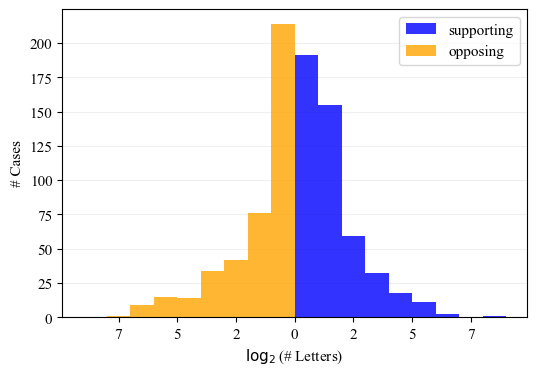

In [45]:
# Distribution of number of letters

plt.figure(figsize=(6,4))
idx1 = df['n_support'] > 0
idx2 = df['n_oppose'] > 0
bins1 = np.arange(0, 10, 1)
bins2 = np.arange(-9, 1, 1)
plt.hist(np.log2(df.loc[idx1, 'n_support']), alpha=0.8, color='blue', label='supporting', bins=bins1)
plt.hist(-np.log2(df.loc[idx2, 'n_oppose']), alpha=0.8, color='orange', label='opposing', bins=bins2)
plt.xlabel(r'$\log_2$(# Letters)')
plt.ylabel('# Cases')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.gca().set_axisbelow(True)
def custom_formatter(xval, pos):
    if xval<0:
        return f"{abs(int(xval))}"
    else:
        return f"{int(xval)}"
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))
#plt.title("Distribution of Support and Opposition Letters by Project")
plt.savefig(os.path.join(LOCAL_PATH, 'figures', 'fig_support_oppose.pdf'), bbox_inches='tight')
#plt.show()

tex = r"""
\begin{figure}[H]
\caption{Distribution of Number of Support and Opposition Letters} \label{fig_support_oppose}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_support_oppose.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note}: Shows distribution of the number of supporting and opposing letters across cases. Cases with zero support or oppose letters are not included in the figure. Note that one case can have multiple supporting \emph{and} opposing letters.}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_support_oppose.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [46]:
# Distribution of support/oppose reasons

support_mask = reasons_df['support_or_oppose'].isin(['DEFINITELY SUPPORT', 'SOMEWHAT SUPPORT'])
oppose_mask = reasons_df['support_or_oppose'].isin(['DEFINITELY OPPOSE', 'SOMEWHAT OPPOSE'])

support_reasons_df = reasons_df.loc[
    support_mask, 
    ['date', 'year', 'doc_id', 'reason']
].drop_duplicates().reset_index(drop=True).groupby('reason').agg(
    num_letters = ('doc_id','count')
).sort_values(by='num_letters', ascending=False).reset_index()

total_support = reasons_df.loc[
    support_mask,
    ['date', 'year', 'doc_id']
].drop_duplicates().shape[0]

oppose_reasons_df = reasons_df.loc[
    oppose_mask,
    ['date', 'year', 'doc_id', 'reason']
].drop_duplicates().reset_index(drop=True).groupby('reason').agg(
    num_letters = ('doc_id','count')
).sort_values(by='num_letters', ascending=False).reset_index()

total_oppose = reasons_df.loc[
    oppose_mask,
    ['date', 'year', 'doc_id']
].drop_duplicates().shape[0]

header = r"""
\begin{table}[H]
\caption{Reasons for Support/Opposition}
\vspace{0.2cm}
\label{tab_reasons}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrlr} \toprule
\multicolumn{2}{c}{\makecell{\# Support letters \\ mentioning}} & \multicolumn{2}{c}{\makecell{\# Oppose letters \\ mentioning}} \\ \midrule
 """
footer = r"""
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows the number of support or oppose letters mentioning each reason. Note that the numbers do not add up to the total number of letters because some letters mention multiple reasons.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""
tbl = ""
for i in range(len(support_reasons_df)):
    tbl += f"{support_reasons_df.loc[i, 'reason']} & {support_reasons_df.loc[i, 'num_letters']:,.0f} & "
    tbl += f"{oppose_reasons_df.loc[i, 'reason']} & {oppose_reasons_df.loc[i, 'num_letters']:,.0f} \\\\ [1ex]\n"
tbl += f"Total support letters & {total_support:,.0f} & Total oppose letters & {total_oppose:,.0f} \\\\ [1ex]"

print(header + tbl + footer)

with open(os.path.join(LOCAL_PATH, "tables", "tab_reasons.tex"), "w", encoding='utf-8') as f:
    f.write(header + tbl + footer)





\begin{table}[H]
\caption{Reasons for Support/Opposition}
\vspace{0.2cm}
\label{tab_reasons}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrlr} \toprule
\multicolumn{2}{c}{\makecell{\# Support letters \\ mentioning}} & \multicolumn{2}{c}{\makecell{\# Oppose letters \\ mentioning}} \\ \midrule
 housing supply / affordability & 1,387 & neighborhood character & 1,583 \\ [1ex]
transit access / walkability & 824 & building height / size / density & 1,311 \\ [1ex]
procedural issues & 794 & procedural issues & 1,240 \\ [1ex]
climate / environment & 677 & community engagement & 1,153 \\ [1ex]
displacement / gentrification & 631 & safety & 1,096 \\ [1ex]
neighborhood character & 574 & traffic / parking & 1,065 \\ [1ex]
building height / size / density & 568 & CEQA related matters & 905 \\ [1ex]
economic impacts / jobs & 538 & housing supply / affordability & 866 \\ [1ex]
homelessness & 511 & climate / environment & 832 \\ [1ex]
CEQA related matters & 507 & dis

In [47]:
# Suffix statistics

sfx_df = pd.read_csv(os.path.join(LOCAL_PATH, "intermediate_data/cpc", "suffix_groups.csv"))

suffixes = sfx_df.sort_values(by='count', ascending=False)['suffix'].tolist()
suffix_grps = sfx_df.groupby('category').agg(
    count = ('count', 'sum')
).reset_index().sort_values(by='count', ascending=False)['category'].tolist()

suffixes
RESULTS = {
    "NumUniqueSuffixes": f"{len(suffixes):.0f}",
    "NumSfxGroups": f"{len(suffix_grps):.0f}"
}

_ = wt.update_results(RESULTS)

RESULTS


{'NumUniqueSuffixes': '77', 'NumSfxGroups': '9'}

In [48]:
# Suffix meanings

header = r"""
\begin{table}[H]
\caption{Case Suffix Meanings and Groupings}
\vspace{0.2cm}
\label{tab_suffixes_all}
\begin{adjustbox}{width=\textwidth}
\begin{threeparttable}
\begin{tabular}{L{1in}C{2in}R{1in}L{5in}C{2in}} \toprule
Suffix & Meaning & Count & Description & Group \\ \midrule
"""
footer = r"""
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows all Planning Department case suffixes present in the dataset, along with their meanings, counts, and assigned groups. The suffixes are grouped into categories based on their meaning and usage.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""
tbl = ""
for i in range(0, len(sfx_df)//2):
    row = sfx_df.iloc[i]
    tbl += f"{row['suffix']} & {row['name']} & {row['count']} & {row['meaning']} & {row['category']} \\\\ [1ex]\n"

print(header + tbl + footer)
with open(os.path.join(LOCAL_PATH, "tables", "tab_suffixes_all.tex"), "w", encoding='utf-8') as f:
    f.write(header + tbl + footer)



\begin{table}[H]
\caption{Case Suffix Meanings and Groupings}
\vspace{0.2cm}
\label{tab_suffixes_all}
\begin{adjustbox}{width=\textwidth}
\begin{threeparttable}
\begin{tabular}{L{1in}C{2in}R{1in}L{5in}C{2in}} \toprule
Suffix & Meaning & Count & Description & Group \\ \midrule
SPR & Site Plan Review & 264 & Indicates that project requires Site Plan Review, a discretionary review required for qualifying projects & Site Plan Review \\ [1ex]
1A & Appeal (1st) & 259 & Indicates that an appeal has been filed against a prior determination in the case & Appeals \\ [1ex]
DB & Density Bonus & 247 & Indicates that the project is using the city's Density Bonus Program which offers density incentives in exchange for providing affordable housing & Incentive Programs \\ [1ex]
CU & Conditional Use & 192 & Indicates that the applicant seeks a Conditional Use Permit & Conditional Use Permits \\ [1ex]
HCA & Housing Crisis Act & 153 & Indicates that the project is subject to the California Housing Crisis

In [49]:
# Suffix meanings (cont'd)

header = r"""
\begin{table}[H]
\caption{Case Suffix Meanings and Groupings (cont'd)}
\vspace{0.2cm}
\label{tab_suffixes_all_2}
\begin{adjustbox}{width=\textwidth}
\begin{threeparttable}
\begin{tabular}{L{1in}C{2in}R{1in}L{5in}C{2in}} \toprule
Suffix & Meaning & Count & Description & Group \\ \midrule
"""
footer = r"""
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows all Planning Department case suffixes present in the dataset, along with their meanings, counts, and assigned groups. The suffixes are grouped into categories based on their meaning and usage.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""
tbl = ""
for i in range(len(sfx_df)//2, len(sfx_df)):
    row = sfx_df.iloc[i]
    tbl += f"{row['suffix']} & {row['name']} & {row['count']} & {row['meaning']} & {row['category']} \\\\ [1ex]\n"

print(header + tbl + footer)
with open(os.path.join(LOCAL_PATH, "tables", "tab_suffixes_all_2.tex"), "w", encoding='utf-8') as f:
    f.write(header + tbl + footer)



\begin{table}[H]
\caption{Case Suffix Meanings and Groupings (cont'd)}
\vspace{0.2cm}
\label{tab_suffixes_all_2}
\begin{adjustbox}{width=\textwidth}
\begin{threeparttable}
\begin{tabular}{L{1in}C{2in}R{1in}L{5in}C{2in}} \toprule
Suffix & Meaning & Count & Description & Group \\ \midrule
PR & Project Review & 10 & Functionally equivalent to Site Plan Review & Site Plan Review \\ [1ex]
DA & Development Agreement & 9 & Indicates that the applicant seeks approval of a development agreement with the City & Development Agreements \\ [1ex]
SPE & Specific Plan Exception & 9 & Indicates that the applicant seeks an exception to the applicable Specific Plan & Variances / Adjustments / Exceptions \\ [1ex]
BSA & Building and Safety Appeal & 9 & Indicates that an appeal has been filed against a prior determination by the Department of Building and Safety & Appeals \\ [1ex]
SPPC & Specific Plan Project Compliance & 8 & Indicates that the project requires review for compliance with an applicable Spec